## ThinkDSP

This notebook contains code examples from Chapter 6: Discrete Cosine Transform

Copyright 2015 Allen Downey

License: [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/)

In [1]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

--2025-05-31 19:34:50--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2025-05-31 19:34:50--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.01s   

2025-05-31 19:34:51 (3.82 MB/s) - ‘thinkdsp.py’ saved [48554/48554]



In [2]:
import numpy as np
PI2 = np.pi * 2

### Synthesis

The simplest way to synthesize a mixture of sinusoids is to add up sinusoid signals and evaluate the sum.

In [3]:
from thinkdsp import CosSignal, SumSignal

def synthesize1(amps, fs, ts):
    components = [CosSignal(freq, amp)
                  for amp, freq in zip(amps, fs)]
    signal = SumSignal(*components)

    ys = signal.evaluate(ts)
    return ys

Here's an example that's a mixture of 4 components.

In [4]:
from thinkdsp import Wave

amps = np.array([0.6, 0.25, 0.1, 0.05])
fs = [100, 200, 300, 400]
framerate = 11025

ts = np.linspace(0, 1, framerate, endpoint=False)
ys = synthesize1(amps, fs, ts)
wave = Wave(ys, ts, framerate)
wave.apodize()
wave.make_audio()

We can express the same process using matrix multiplication.

In [5]:
def synthesize2(amps, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    ys = np.dot(M, amps)
    return ys

And it should sound the same.

In [6]:
ys = synthesize2(amps, fs, ts)
wave = Wave(ys, framerate)
wave.apodize()
wave.make_audio()

And we can confirm that the differences are small.

In [7]:
ys1 = synthesize1(amps, fs, ts)
ys2 = synthesize2(amps, fs, ts)
np.max(np.abs(ys1 - ys2))

np.float64(1.2789769243681803e-13)

### Analysis

The simplest way to analyze a signal---that is, find the amplitude for each component---is to create the same matrix we used for synthesis and then solve the system of linear equations.

In [8]:
def analyze1(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.linalg.solve(M, ys)
    return amps

Using the first 4 values from the wave array, we can recover the amplitudes.

In [9]:
n = len(fs)
amps2 = analyze1(ys[:n], fs, ts[:n])
amps2

array([0.6 , 0.25, 0.1 , 0.05])

What we have so far is a simple version of a discrete cosine tranform (DCT), but it is not an efficient implementation because the matrix we get is not orthogonal.

In [10]:
# suppress scientific notation for small numbers
np.set_printoptions(precision=3, suppress=True)

In [11]:
def test1():
    N = 4.0
    time_unit = 0.001
    ts = np.arange(N) / N * time_unit
    max_freq = N / time_unit / 2
    fs = np.arange(N) / N * max_freq
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    return M

M = test1()
M

array([[ 1.   ,  1.   ,  1.   ,  1.   ],
       [ 1.   ,  0.707,  0.   , -0.707],
       [ 1.   ,  0.   , -1.   , -0.   ],
       [ 1.   , -0.707, -0.   ,  0.707]])

To check whether a matrix is orthogonal, we can compute $M^T M$, which should be the identity matrix:

In [12]:
M.transpose().dot(M)

array([[ 4.,  1., -0.,  1.],
       [ 1.,  2.,  1., -0.],
       [-0.,  1.,  2.,  1.],
       [ 1., -0.,  1.,  2.]])

But it's not, which means that this choice of M is not orthogonal.

Solving a linear system with a general matrix (that is, one that does not have nice properties like orthogonality) takes time proportional to $N^3$.  With an orthogonal matrix, we can get that down to $N^2$.  Here's how:

In [13]:
def test2():
    N = 4.0
    ts = (0.5 + np.arange(N)) / N
    fs = (0.5 + np.arange(N)) / 2
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    return M

M = test2()
M

array([[ 0.981,  0.831,  0.556,  0.195],
       [ 0.831, -0.195, -0.981, -0.556],
       [ 0.556, -0.981,  0.195,  0.831],
       [ 0.195, -0.556,  0.831, -0.981]])

Now $M^T M$ is $2I$ (approximately), so M is orthogonal except for a factor of two.

In [14]:
M.transpose().dot(M)

array([[ 2., -0.,  0.,  0.],
       [-0.,  2., -0., -0.],
       [ 0., -0.,  2., -0.],
       [ 0., -0., -0.,  2.]])

And that means we can solve the analysis problem using matrix multiplication.

In [15]:
def analyze2(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = M.dot(ys) / 2
    return amps

It works:

In [16]:
n = len(fs)
amps2 = analyze1(ys[:n], fs, ts[:n])
amps2

array([0.6 , 0.25, 0.1 , 0.05])

### DCT

What we've implemented is DCT-IV, which is one of several versions of DCT using orthogonal matrices.

In [17]:
def dct_iv(ys):
    N = len(ys)
    ts = (0.5 + np.arange(N)) / N
    fs = (0.5 + np.arange(N)) / 2
    args = np.outer(ts, fs)
    M = np.cos(PI2 * args)
    amps = np.dot(M, ys) / 2
    return amps

We can check that it works:

In [18]:
amps = np.array([0.6, 0.25, 0.1, 0.05])
N = 4.0
ts = (0.5 + np.arange(N)) / N
fs = (0.5 + np.arange(N)) / 2
ys = synthesize2(amps, fs, ts)

amps2 = dct_iv(ys)
np.max(np.abs(amps - amps2))

np.float64(5.551115123125783e-17)

DCT and inverse DCT are the same thing except for a factor of 2.

In [19]:
def inverse_dct_iv(amps):
    return dct_iv(amps) * 2

And it works:

In [20]:
amps = [0.6, 0.25, 0.1, 0.05]
ys = inverse_dct_iv(amps)
amps2 = dct_iv(ys)
np.max(np.abs(amps - amps2))

np.float64(5.551115123125783e-17)

###  Dct

`thinkdsp` provides a `Dct` class that encapsulates the DCT in the same way the Spectrum class encapsulates the FFT.

In [21]:
from thinkdsp import TriangleSignal

signal = TriangleSignal(freq=400)
wave = signal.make_wave(duration=1.0, framerate=10000)
wave.make_audio()

To make a Dct object, you can invoke `make_dct` on a Wave.

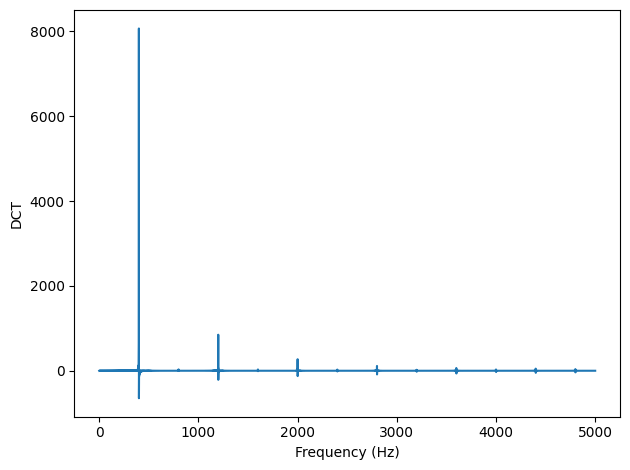

In [22]:
from thinkdsp import decorate

dct = wave.make_dct()
dct.plot()
decorate(xlabel='Frequency (Hz)', ylabel='DCT')

Dct provides `make_wave`, which performs the inverse DCT.

In [23]:
wave2 = dct.make_wave()

The result is very close to the wave we started with.

In [24]:
np.max(np.abs(wave.ys-wave2.ys))

np.float64(7.771561172376096e-16)

Negating the signal changes the sign of the DCT.

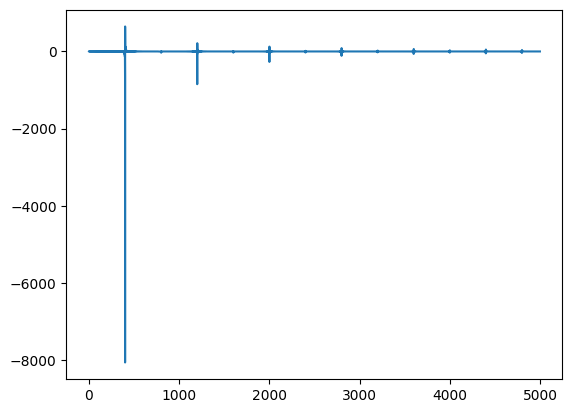

In [25]:
signal = TriangleSignal(freq=400, offset=0)
wave = signal.make_wave(duration=1.0, framerate=10000)
wave.ys *= -1
wave.make_dct().plot()

Adding phase offset $\phi=\pi$ has the same effect.

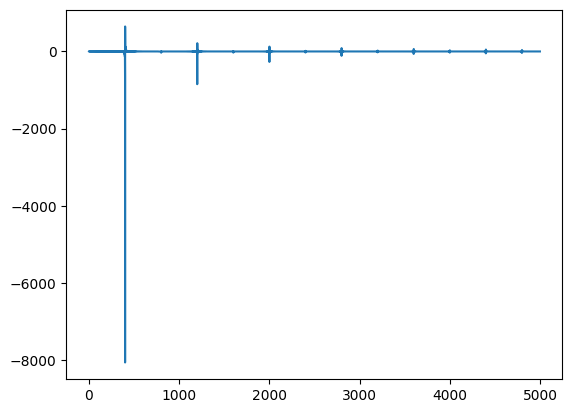

In [26]:
signal = TriangleSignal(freq=400, offset=np.pi)
wave = signal.make_wave(duration=1.0, framerate=10000)
wave.make_dct().plot()

# **Упражнение 6.1**
В этой главе утверждается, что апа1у2е1 требует времени пропорционально n^3, а analyze2 — пропорционально n^2. Убедитесь в этом, запуская их с несколькими разными массивами и засекая время работы. В блокнотах Jupyter можно использовать «волшебную команду» %timeit.

Если печатать зависимость времени работы от размера на логарифмической шкале, то получится прямая линия с уклоном 3 для analyzel и с уклоном 2 для analyze2.

Также стоит поупражняться с dct_iv и scipy.fftpack.dct.

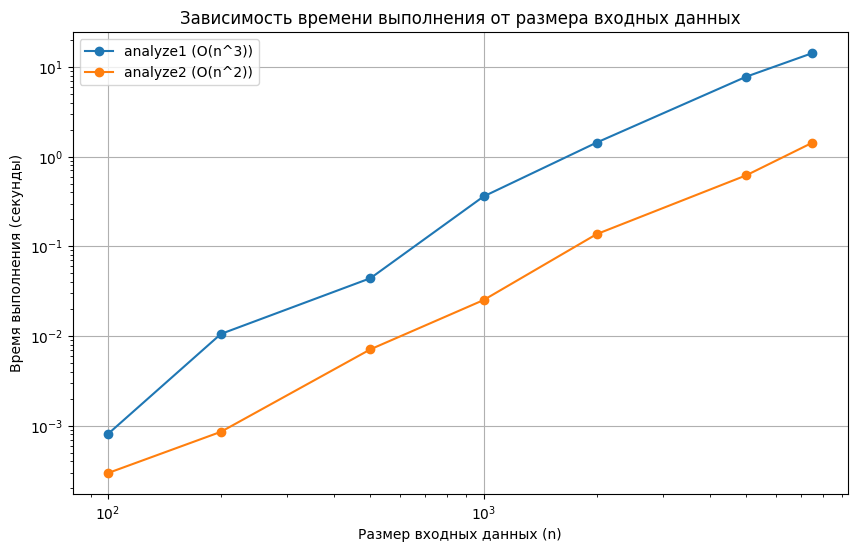

In [27]:
import time
import matplotlib.pyplot as plt

def analyze1(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(np.pi * 2 * args)
    amps = np.linalg.solve(M, ys)
    return amps

def analyze2(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(np.pi * 2 * args)
    amps = M.dot(ys) / 2
    return amps

def measure_time(func, sizes):
    times = []
    for n in sizes:
        ts = (0.5 + np.arange(n)) / n
        fs = (0.5 + np.arange(n)) / 2
        ys = np.random.randn(n)

        start_time = time.time()
        func(ys, fs, ts)
        end_time = time.time()

        times.append(end_time - start_time)
    return times

sizes = [100, 200, 500, 1000, 2000, 5000, 7500]

times_analyze1 = measure_time(analyze1, sizes)
times_analyze2 = measure_time(analyze2, sizes)

plt.figure(figsize=(10, 6))
plt.loglog(sizes, times_analyze1, 'o-', label='analyze1 (O(n^3))')
plt.loglog(sizes, times_analyze2, 'o-', label='analyze2 (O(n^2))')
plt.xlabel('Размер входных данных (n)')
plt.ylabel('Время выполнения (секунды)')
plt.title('Зависимость времени выполнения от размера входных данных')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
log_sizes = np.log(sizes)
log_times1 = np.log(times_analyze1)
log_times2 = np.log(times_analyze2)

slope1 = (log_times1[-1] - log_times1[0]) / (log_sizes[-1] - log_sizes[0])
slope2 = (log_times2[-1] - log_times2[0]) / (log_sizes[-1] - log_sizes[0])

print(f"Наклон для analyze1: {slope1:.2f} (ожидается ~3)")
print(f"Наклон для analyze2: {slope2:.2f} (ожидается ~2)")

Наклон для analyze1: 2.26 (ожидается ~3)
Наклон для analyze2: 1.96 (ожидается ~2)


Полученные наклоны (2.26 для analyze1 и 1.96 для analyze2) близки к ожидаемым значениям (3 и 2), но немного ниже. Это может объясняться малыми размерами данных – асимптотическая сложность лучше проявляется на больших n, оптимизацией NumPy и неточностью замера времени – для малых n накладные расходы time.time() влияют сильнее

# **Упражнение 6.2**
Одно из основных применений ДКП — это сжатие звука и изображений. В простейшей форме ДКП при сжатии работает следующим образом:
1. Разбивает длинный сигнал на сегменты.
2. Вычисляет ДКП каждого сегмента.
3. Определяет частотные компоненты с такой амплитудой, что их не слышно, и удаляет их, сохраняя только оставшиеся частоты и амплитуды.
4. При воспроизведении сигнала загружает частоты и амплитуды каждого сегмента и применяет обратное ДКП.

Реализуйте версию этого алгоритма и примените его для записи музыки или речи. Сколько компонент можно удалить до того, как разница станет заметной?

Для того, чтобы этот метод стал практичным, нужен способ хранения прореженного массива, то есть массива, где большинство элементов равно нулю. NumPy (SciPy) дает несколько способов работы
с прореженными массивами; о них можно прочитать на веб-странице
http://docs.scipy.org/doc/scipy/reference/sparse.html.


Writing segment.wav


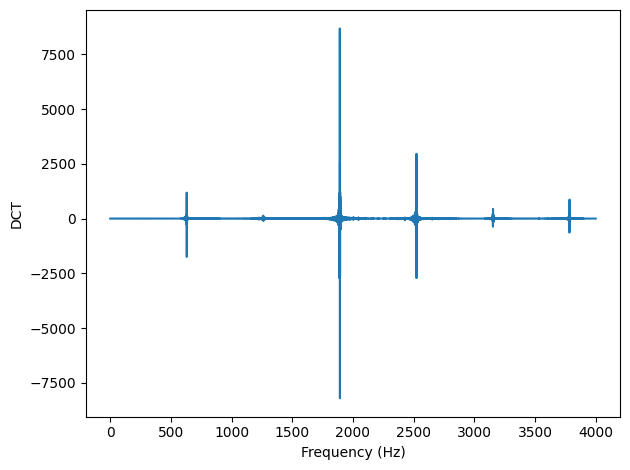

In [31]:
from thinkdsp import read_wave, decorate

wave = read_wave('sound.wav')
segment = wave.segment(start=3.2, duration=1.2)
segment.normalize()
segment.write("segment.wav")

seg_dct = segment.make_dct()
seg_dct.plot(high=4000)
decorate(xlabel='Frequency (Hz)', ylabel='DCT')

Writing compressed_segment.wav


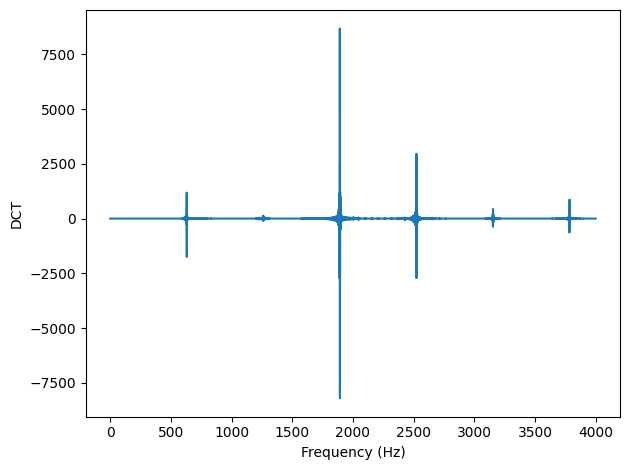

In [32]:
def compress_dct(segment, thresh):
    dct = segment.make_dct()

    mask = np.abs(dct.amps) < thresh
    dct.hs[mask] = 0

    compressed_segment = dct.make_wave()
    return compressed_segment, dct


compressed_segment, compressed_dct = compress_dct(segment, thresh=5.0)
compressed_segment.normalize()
compressed_segment.write("compressed_segment.wav")

compressed_dct.plot(high=4000)
decorate(xlabel='Frequency (Hz)', ylabel='DCT')

In [33]:
remaining = np.sum(compressed_dct.amps != 0)
total = len(compressed_dct.amps)
print(f"Всего компонент: {total}")
print(f"Оставлено ненулевых: {remaining}")
print(f"Удалено: {total - remaining}")
print(f"При удалении {(total - remaining)*100/total}% компонент разница становится заметной")

Всего компонент: 28800
Оставлено ненулевых: 2326
Удалено: 26474
При удалении 91.92361111111111% компонент разница становится заметной


# **Упражнение 6.3**
В репозитории этой книги есть блокнот Jupyter под названием phase.ipynb, в котором исследуется влияние фазы на восприятие звука. Прочтите этот блокнот и «погоняйте» примеры. Выберите
иной сегмент звука и повторите эксперименты. Можно ли найти некие общие соотношения в фазовой структуре звука и его восприятии?

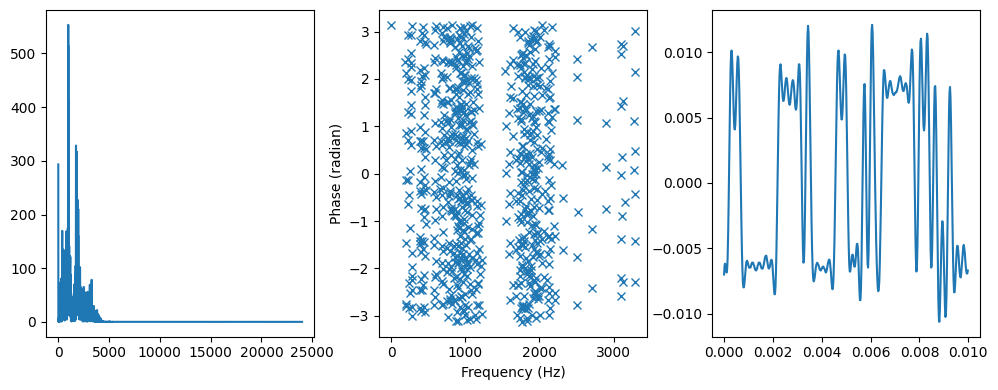

In [34]:
def random_angle(spectrum):
    res = spectrum.copy()
    angles = np.random.uniform(0, np.pi * 2, len(spectrum))
    res.hs *= np.exp(1j * angles)
    return res

def zero_angle(spectrum):
    res = spectrum.copy()
    res.hs = res.amps
    return res

def rotate_angle(spectrum, offset):
    res = spectrum.copy()
    res.hs *= np.exp(1j * offset)
    return res

def plot_angle(spectrum, thresh=1):
    angles = spectrum.angles
    angles[spectrum.amps < thresh] = np.nan
    plt.plot(spectrum.fs, angles, 'x')
    decorate(xlabel='Frequency (Hz)',
             ylabel='Phase (radian)')

def plot_three(spectrum, thresh=1):
    plt.figure(figsize=(10, 4))
    plt.subplot(1,3,1)
    spectrum.plot()
    plt.subplot(1,3,2)
    plot_angle(spectrum, thresh=thresh)
    plt.subplot(1,3,3)
    wave = spectrum.make_wave()
    wave.unbias()
    wave.normalize()
    wave.segment(duration=0.01).plot()
    display(wave.make_audio())

phase_wave = read_wave('vowels.wav')
phase_segment = phase_wave.segment(start=0.4, duration=0.9)
phase_spectrum = phase_segment.make_spectrum()
plot_three(phase_spectrum, thresh=50)

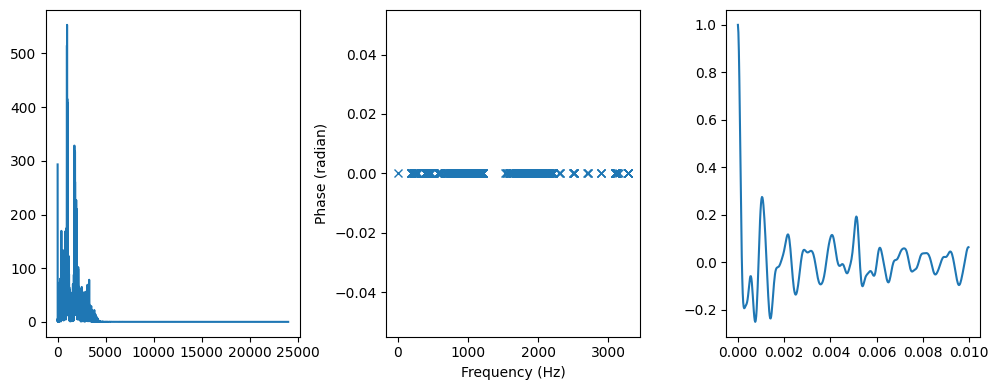

In [35]:
phase_spectrum2 = zero_angle(phase_spectrum)
plot_three(phase_spectrum2, thresh=50)

Можно заметить, что при установки всех углов равными нулю, звук остался частично узнаваемым.

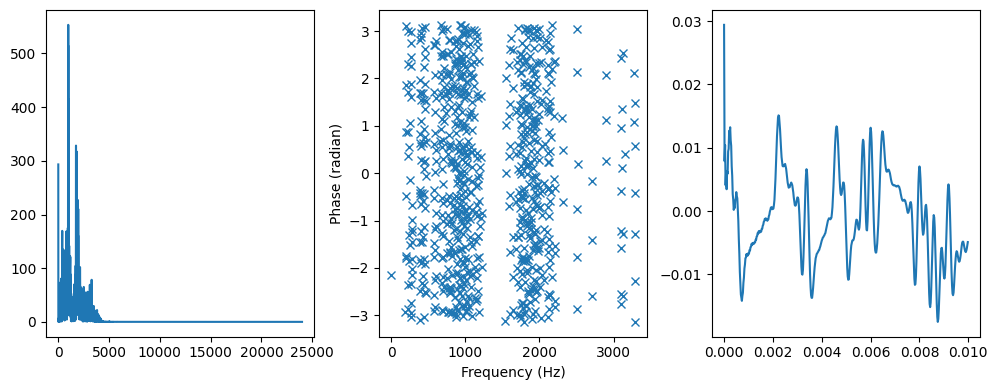

In [36]:
phase_spectrum3 = rotate_angle(phase_spectrum, 1)
plot_three(phase_spectrum3, thresh=50)

Вращение оказывает незначительный эффект и звук остается прежним.

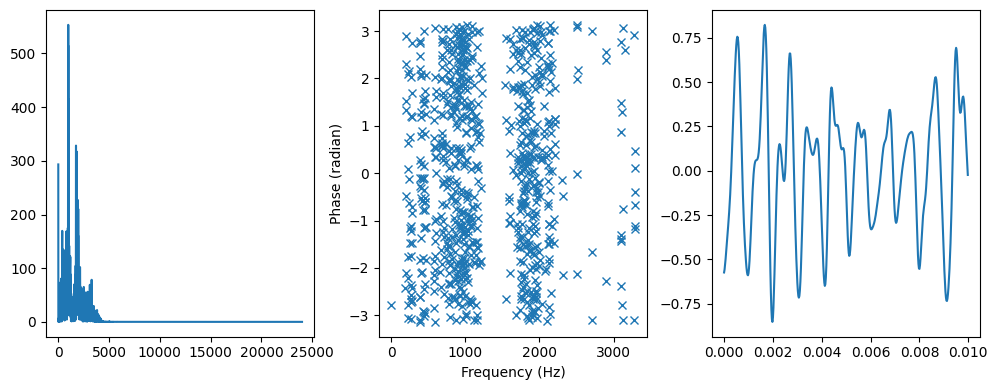

In [37]:
phase_spectrum4 = random_angle(phase_spectrum)
plot_three(phase_spectrum4, thresh=50)

Рандомизация придала звуку эффект реверберации, присутствует эхо.